# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [2]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [3]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [4]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [5]:
# f_0 change, L_0 fixed

fixed_width = 600_000.0  # 600 km


case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

#L_0 change, f_0 fixed

fixed_latitude = 35.0
width_case_names = []
width_run_params = []
width_runs = {}
for width in [200_000.0, 600_000.0, 1_200_000.0, 2_400_000.0]:
    f = coriolis_parameter(fixed_latitude)
    case_label = f"L_0={width/1000:.0f} km"
    print(f"Integrating {case_label} ...")
    width_case_names.append(case_label)
    width_run_params.append({"label": case_label, "latitude": fixed_latitude, "f_0": f, "amplitude": h_0, "width": width})
    width_runs[case_label] = integrate_case(f, amplitude=h_0, width=width)



Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...
Integrating L_0=200 km ...
Integrating L_0=600 km ...
Integrating L_0=1200 km ...
Integrating L_0=2400 km ...


## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

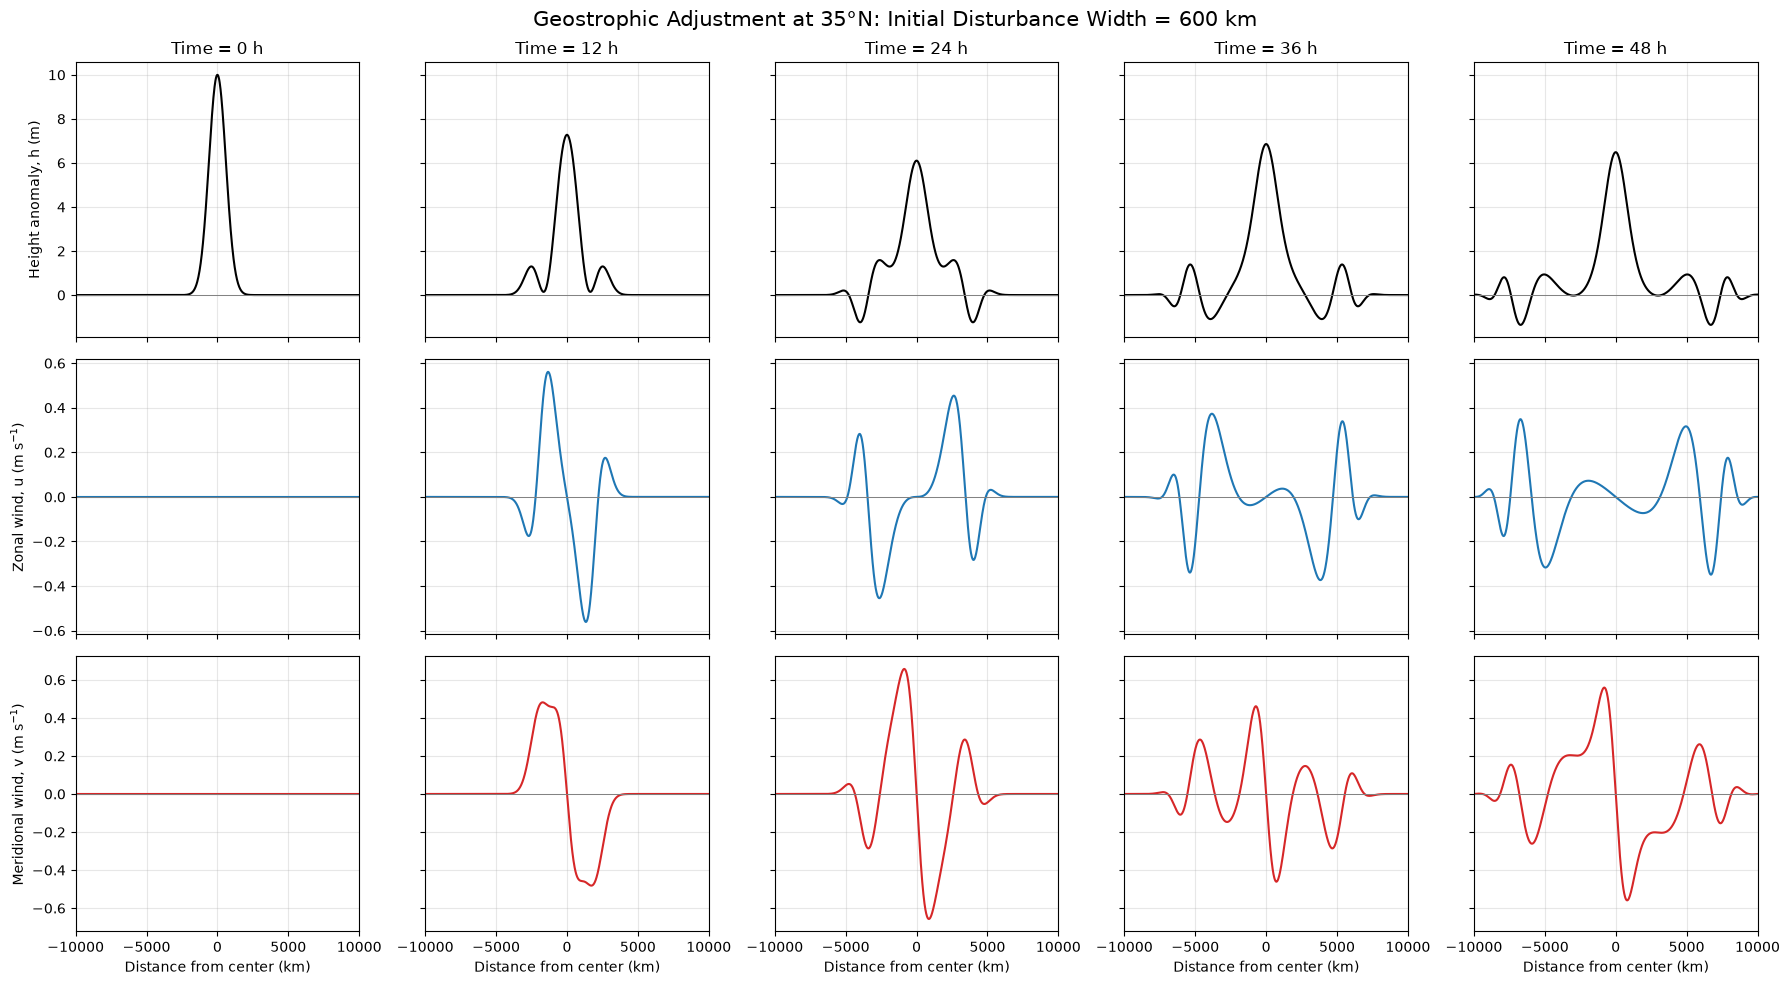

In [6]:
# Plot 1: Geostrophic adjustment at 35°N with a 600 km initial disturbance

latitude = 35.0
width_600km = 600_000.0
f_35 = coriolis_parameter(latitude)

run_35_600 = integrate_case(
    f_35,
    amplitude=h_0,
    width=width_600km
)

x_km = run_35_600["x"] / 1000
time_hours = run_35_600["time"] / 3600
snapshot_hours = [0, 12, 24, 36, 48]

fig, axes = plt.subplots(
    3, len(snapshot_hours),
    figsize=(18, 10),
    sharex=True,
    sharey="row"
)

for column, requested_hour in enumerate(snapshot_hours):
    time_index = np.argmin(np.abs(time_hours - requested_hour))
    actual_hour = time_hours[time_index]

    axes[0, column].plot(x_km, run_35_600["h"][time_index], color="black")
    axes[1, column].plot(x_km, run_35_600["u"][time_index], color="tab:blue")
    axes[2, column].plot(x_km, run_35_600["v"][time_index], color="tab:red")

    for row in range(3):
        axes[row, column].axhline(0, color="gray", linewidth=0.7)
        axes[row, column].set_xlim(-10000, 10000)
        axes[row, column].grid(alpha=0.3)

    axes[0, column].set_title(f"Time = {actual_hour:.0f} h")

axes[0, 0].set_ylabel("Height anomaly, h (m)")
axes[1, 0].set_ylabel("Zonal wind, u (m s$^{-1}$)")
axes[2, 0].set_ylabel("Meridional wind, v (m s$^{-1}$)")

for ax in axes[2, :]:
    ax.set_xlabel("Distance from center (km)")

fig.suptitle(
    "Geostrophic Adjustment at 35°N: Initial Disturbance Width = 600 km",
    fontsize=15
)

plt.tight_layout()
plt.show()

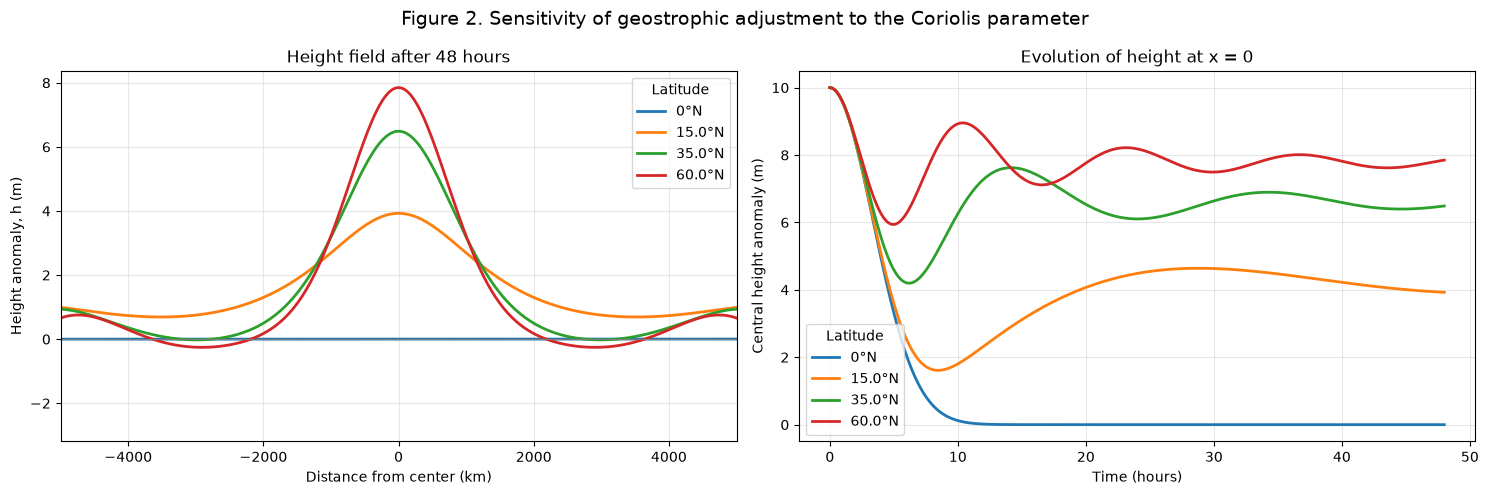

In [7]:
# Figure 2: Sensitivity to f_0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: final height profiles
for case_name, run in runs.items():
    axes[0].plot(
        run["x"] / 1000,
        run["h"][-1],
        linewidth=2,
        label=case_name
    )

axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].set_xlim(-5000, 5000)
axes[0].set_xlabel("Distance from center (km)")
axes[0].set_ylabel("Height anomaly, h (m)")
axes[0].set_title("Height field after 48 hours")
axes[0].legend(title="Latitude")
axes[0].grid(alpha=0.3)


# Right panel: height at the center over time
for case_name, run in runs.items():
    center_index = len(run["x"]) // 2

    axes[1].plot(
        run["time"] / 3600,
        run["h"][:, center_index],
        linewidth=2,
        label=case_name
    )

axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Central height anomaly (m)")
axes[1].set_title("Evolution of height at x = 0")
axes[1].legend(title="Latitude")
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Figure 2. Sensitivity of geostrophic adjustment to the Coriolis parameter",
    fontsize=14
)

plt.tight_layout()
plt.show()

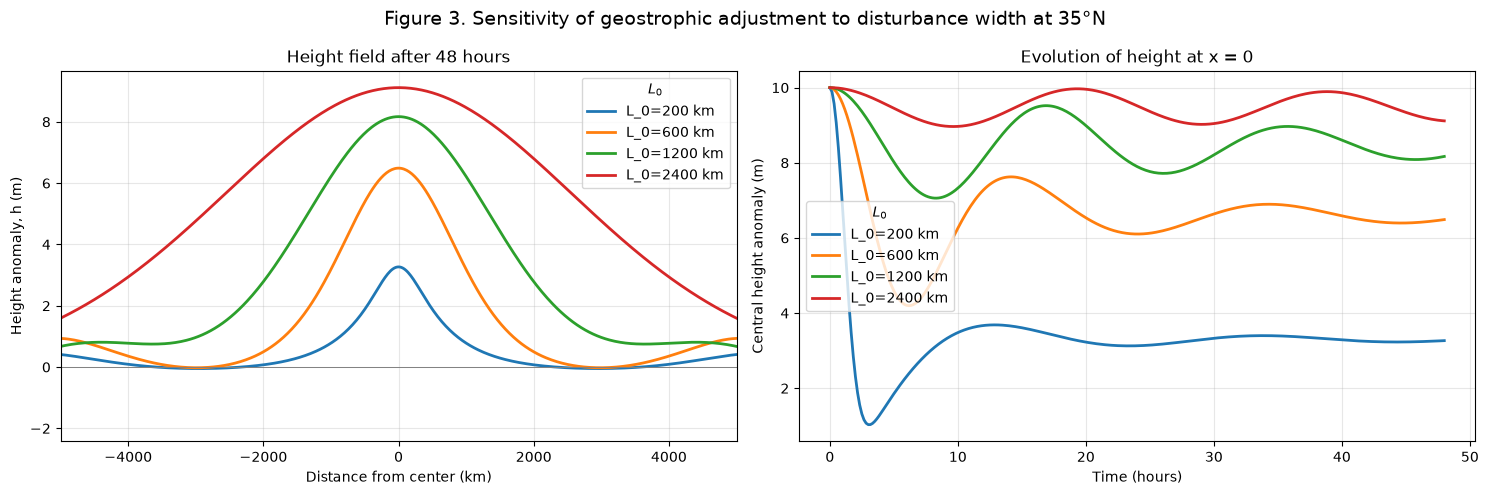

In [8]:
# Figure 3: Sensitivity to initial disturbance width L_0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: final height profiles
for case_name, run in width_runs.items():
    axes[0].plot(
        run["x"] / 1000,
        run["h"][-1],
        linewidth=2,
        label=case_name
    )

axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].set_xlim(-5000, 5000)
axes[0].set_xlabel("Distance from center (km)")
axes[0].set_ylabel("Height anomaly, h (m)")
axes[0].set_title("Height field after 48 hours")
axes[0].legend(title="$L_0$")
axes[0].grid(alpha=0.3)


# Right panel: height at the center over time
for case_name, run in width_runs.items():
    center_index = len(run["x"]) // 2

    axes[1].plot(
        run["time"] / 3600,
        run["h"][:, center_index],
        linewidth=2,
        label=case_name
    )

axes[1].set_xlabel("Time (hours)")
axes[1].set_ylabel("Central height anomaly (m)")
axes[1].set_title("Evolution of height at x = 0")
axes[1].legend(title="$L_0$")
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Figure 3. Sensitivity of geostrophic adjustment to disturbance width at 35°N",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [11]:
# Diagnostics

def calculate_diagnostics(run, experiment_group, case_name):

    f_abs = abs(run["f_0"])
    width = run["width"]

    # Wind speed at every saved position and time
    wind_speed = np.sqrt(run["u"]**2 + run["v"]**2)

    # Maximum wind speed over all positions and times
    U = np.max(wind_speed)

    # f_0 = 0 makes L_D, Bu, and Ro undefined
    if f_abs == 0:
        deformation_radius = np.nan
        burger_number = np.nan
        rossby_number = np.nan
    else:
        deformation_radius = np.sqrt(G * H) / f_abs
        burger_number = (deformation_radius / width)**2
        rossby_number = U / (f_abs * width)

    center_index = len(run["x"]) // 2
    final_center_height = run["h"][-1, center_index]

    return {
        "Experiment": experiment_group,
        "Case": case_name,
        "f_0 (s^-1)": run["f_0"],
        "L_0 (km)": width / 1000,
        "Maximum U (m/s)": U,
        "L_D (km)": deformation_radius / 1000,
        "Bu": burger_number,
        "Ro": rossby_number,
        "Final center h (m)": final_center_height
    }


# Calculate values for every scenario


diagnostic_rows = []

for case_name, run in runs.items():
    diagnostic_rows.append(
        calculate_diagnostics(
            run,
            experiment_group="Varying f_0",
            case_name=case_name
        )
    )

for case_name, run in width_runs.items():
    diagnostic_rows.append(
        calculate_diagnostics(
            run,
            experiment_group="Varying L_0",
            case_name=case_name
        )
    )

diagnostic_table = pd.DataFrame(diagnostic_rows)

# Display rounded values with appropriate sig figs
display(diagnostic_table.round({
    "f_0 (s^-1)": 7,
    "L_0 (km)": 1,
    "Maximum U (m/s)": 3,
    "L_D (km)": 1,
    "Bu": 3,
    "Ro": 4,
    "Final center h (m)": 3
}))

,Experiment,Case,f_0 (s^-1),L_0 (km),Maximum U (m/s),L_D (km),Bu,Ro,Final center h (m)
0,Varying f_0,0°N,0.000000,600.0,0.990,NaN,NaN,NaN,-0.000
1,Varying f_0,15.0°N,0.000038,600.0,0.981,1312.0,4.781,0.0433,3.926
2,Varying f_0,35.0°N,0.000084,600.0,0.975,592.0,0.974,0.0194,6.489
3,Varying f_0,60.0°N,0.000126,600.0,0.925,392.1,0.427,0.0122,7.849
4,Varying L_0,L_0=200 km,0.000084,200.0,0.983,592.0,8.762,0.0588,3.267
5,Varying L_0,L_0=600 km,0.000084,600.0,0.975,592.0,0.974,0.0194,6.489
6,Varying L_0,L_0=1200 km,0.000084,1200.0,0.833,592.0,0.243,0.0083,8.169
7,Varying L_0,L_0=2400 km,0.000084,2400.0,0.531,592.0,0.061,0.0026,9.115


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

For a rotating experiment, the geostrophic adjustment process begins by the initial height perturbation, or anomaly, which is caused by the pressure gradient force. The height is greatest at the initial position, or x=0, and the pressure gradient force pushes air outward from the initial perturbation. This causes the u-wnd to be divergent as you get further from the initial position. As air begins to move, the coriolis force acts on the wind and produces a non-zero v-wind. Figure 1 shows that the air from the initial height anomaly from the intial perturbation, at t=0, begins to move outward in gravity-inertial waves, as seen at t=12 hrs. These waves move with oscillatory motions as they continue to move away from x=0, as well as inverse u-winds occuring. While this is happening, the bulk of the height anomaly is still centered over x=0. In later times, such as t=36 hrs or t=48 hrs, u-wind becomes relatively weak, while v-wind remains consistent with the horizontal height gradient. This indicates that the pressure gradient force and the Coriolis force are trying to reach geostrophic balance, thus, the geostrophic adjustment. After this, there is almost a balanced central remnant at the center, while outward-propogating waves carry the rest of the unbalanced portion of the intial perturbation away. 

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

Changing f_0 affects the amount of the intial height anomaly remains at the center. Figure 2 shows that the experiment done at f_0=0 degrees has almost no height anomaly left after 48 hours. When f_0=0 degrees, there is no Coriolis force, thus, geostrophic balance cannot occur. The initial perturbation turns into outward-propogating gravity waves that move away from the initial position of the perturbation. As f_0 increases, the central anomalies remain much larger. The central anomalies were 3.926m at 15 degrees N, 6.489m at 35 degrees N, and 7.849m at 60 degrees N. The Burger Number also decreases from about 4.781 to 0.427 as you increase the latitude. The smaller L_d and Bu indicates that rotational effects gain more importance as the distance decreases relative to the width of the disturbance. This also means that rotation causes a more central remnant of the intial disturbance as it prohibits the perturbation from spreading out. The Rossby Number also decreases as f_0 increases, which means that rotation becomes more important when it comes to inertial motion. Changing L_0 produces a similar sensitivity, even though f_0 and L_d remain constant. Figure 3 and the table of values show that the final center height with the intiial width of 200km is 3.267m, but 9.115m with the initial width of 2400km. For the perturbation where L_0=200km, L_0 is much smaller than L_d, making the Burger Number 8.762. This causes a larger fraction of the perturbation to move outward as gravity plays a more significant role. This changes as the disturbances become broader, meaning Bu decreases drastically when L_0 is less than Bu. At the 2400km scale, Bu=0.061, meaning rotation has a major role on the scale of the disturbance. This means that the center of the initial disturbance retains the bulk of the 10m height anomaly. The Rossby number also decreases from 0.0588 at a 200km width to 0.0026 at a 2400km width. This means that both an increase in f_0 and L_0 decrease the Rossby number. One big difference between changing f_0 and L_0 is that a change in f_0 changed L_d, but a change in L_0 changes the size of the disturbance relative to the width of the disturbance.

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?

Something that I understand better after this lab is how the height anomalies and v-wind are interconnected. V-winds continue to fluctuate depending on the horizontal height gradient, which aligns with the pressure gradient force, which is one of the major parts of geostrophic balance. Also, it is interesting how gravity waves continue to propogate outward to complete the geostrophic adjustment process. In terms of coding, this lab taught me how to store outputs in dictionaries, then alowed me to use those dictionaries later in the code to complete my figures. 

**Academic Integrity Statement**- As a graduate student at the Univerisity of Oklahoma, it is my duty to inform the reader of AI usage in this lab. Generative AI was used in the making of this lab, including Microsoft Copilot and ChatGPT. These were supplementary sources that I used to troubleshoot code, improve the visualizations with my figures, and increase organization within the project. I made sure to revise, evaluate, and verify all AI suggestions. The analysis, conclusions, and interpretations of the data were all my own work. 